# Baseline Models — LSST Classification

Four baselines, all trained from scratch (no pre-training):
1. **LightGBM (flat)** — raw flattened 36×6=216 features, temporally blind
2. **LightGBM (stats)** — 5 hand-crafted statistics per passband = 30 features, temporally blind
3. **ROCKET + Ridge** — random convolutional kernels, time-aware
4. **MultiROCKET + Ridge** — multi-feature ROCKET variant (PPV, mean, std of positive values & indices), time-aware

All evaluated with **macro-F1** (fair under severe class imbalance) and **accuracy**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import RidgeClassifierCV
from sklearn.metrics import f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_sample_weight
import lightgbm as lgb
from sktime.transformations.panel.rocket import Rocket, MultiRocket
from tslearn.datasets import UCR_UEA_datasets
import warnings
warnings.filterwarnings('ignore')

## 1. Load Data

In [2]:
ds = UCR_UEA_datasets()
X_train, y_train, X_test, y_test = ds.load_dataset('LSST')

print(f'X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape}   y_test:  {y_test.shape}')

X_train: (2459, 36, 6)  y_train: (2459,)
X_test:  (2466, 36, 6)   y_test:  (2466,)


## 2. Preprocessing

**Per-sample z-score over the time axis:** for each sample and each passband independently,
subtract the mean and divide by the std computed over its 36 timesteps.
This removes absolute brightness differences between objects and focuses the model on the *shape* of the light curve.
It also prevents the two extreme-CoV classes (62, 64) from dominating.

**Class weights:** computed from training label frequencies and passed to each model to handle the 111× imbalance.

In [3]:
def zscore_per_sample(X):
    """Z-score each (sample, passband) series over its 36 timesteps."""
    mu  = X.mean(axis=1, keepdims=True)   # (n, 1, 6)
    sig = X.std(axis=1, keepdims=True) + 1e-8
    return (X - mu) / sig

X_train_z = zscore_per_sample(X_train)  # (2459, 36, 6)
X_test_z  = zscore_per_sample(X_test)

sample_weights = compute_sample_weight('balanced', y_train)

classes = sorted(set(y_train))
n_classes = len(classes)
print(f'Normalised. Sample weight range: [{sample_weights.min():.3f}, {sample_weights.max():.3f}]')

Normalised. Sample weight range: [0.226, 25.092]


## 3. Feature Extraction

### Flat features (216-dim)
Concatenate all 6 passbands end-to-end: timestep 0–35 of u, then g, …, then y.
The model sees all raw values but has no notion of ordering.

### Hand-crafted stats features (30-dim)
For each of the 6 passbands: mean, std, min, max, CoV (= std/|mean|). Compact summary of each light curve's shape per band.

In [4]:
# Flat: (n, 36*6=216)
X_train_flat = X_train_z.reshape(len(X_train_z), -1)
X_test_flat  = X_test_z.reshape(len(X_test_z),  -1)

# Hand-crafted stats: (n, 5*6=30)
def make_stats(X):
    mu   = X.mean(axis=1)                          # (n, 6)
    sig  = X.std(axis=1)                           # (n, 6)
    mn   = X.min(axis=1)                           # (n, 6)
    mx   = X.max(axis=1)                           # (n, 6)
    cov  = sig / (np.abs(mu) + 1e-8)              # (n, 6)
    return np.concatenate([mu, sig, mn, mx, cov], axis=1)  # (n, 30)

X_train_stats = make_stats(X_train_z)
X_test_stats  = make_stats(X_test_z)

print(f'Flat features:  {X_train_flat.shape}')
print(f'Stats features: {X_train_stats.shape}')

Flat features:  (2459, 216)
Stats features: (2459, 30)


## 4. Evaluation Helper

In [5]:
results = {}      # {name: {'macro_f1': float, 'acc': float}}
all_preds = {}    # {name: y_pred} for confusion matrices

def evaluate(name, y_true, y_pred):
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    acc       = (y_true == y_pred).mean()
    results[name]   = {'macro_f1': macro_f1, 'acc': acc}
    all_preds[name] = y_pred
    print(f'\n=== {name} ===')
    print(f'  Accuracy:  {acc*100:.2f}%')
    print(f'  Macro-F1:  {macro_f1:.4f}')
    print(classification_report(y_true, y_pred, digits=3))

## 5. LightGBM — Flat Features (216-dim)

Class imbalance is handled via `sample_weight` passed during training.

In [6]:
lgbm_flat = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    random_state=42,
    n_jobs=4,
    verbosity=-1,
)
lgbm_flat.fit(X_train_flat, y_train, sample_weight=sample_weights)
pred_flat = lgbm_flat.predict(X_test_flat)
evaluate('LightGBM (flat 216)', y_test, pred_flat)


=== LightGBM (flat 216) ===
  Accuracy:  55.68%
  Macro-F1:  0.2922
              precision    recall  f1-score   support

          15      0.702     0.323     0.442       124
          16      0.675     0.885     0.766       270
          42      0.468     0.369     0.413       382
          52      0.500     0.016     0.031        63
          53      0.000     0.000     0.000         7
           6      0.000     0.000     0.000        35
          62      0.208     0.033     0.056       153
          64      0.000     0.000     0.000        24
          65      0.571     0.626     0.598       313
          67      0.333     0.029     0.054        68
          88      0.830     0.769     0.798       121
          90      0.521     0.830     0.640       777
          92      0.375     0.078     0.129        77
          95      0.556     0.096     0.164        52

    accuracy                          0.557      2466
   macro avg      0.410     0.290     0.292      2466
weighted av

## 6. LightGBM — Hand-crafted Stats Features (30-dim)

Same hyperparameters; fewer but more structured features.

In [7]:
lgbm_stats = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    n_jobs=4,
    random_state=42,
    verbosity=-1,
)
lgbm_stats.fit(X_train_stats, y_train, sample_weight=sample_weights)
pred_stats = lgbm_stats.predict(X_test_stats)
evaluate('LightGBM (stats 30)', y_test, pred_stats)


=== LightGBM (stats 30) ===
  Accuracy:  65.82%
  Macro-F1:  0.5017
              precision    recall  f1-score   support

          15      0.616     0.492     0.547       124
          16      0.965     0.919     0.941       270
          42      0.508     0.440     0.471       382
          52      0.000     0.000     0.000        63
          53      0.636     1.000     0.778         7
           6      0.440     0.314     0.367        35
          62      0.414     0.235     0.300       153
          64      0.167     0.042     0.067        24
          65      0.699     0.802     0.747       313
          67      0.364     0.118     0.178        68
          88      0.796     0.901     0.845       121
          90      0.632     0.833     0.718       777
          92      0.864     0.909     0.886        77
          95      0.400     0.115     0.179        52

    accuracy                          0.658      2466
   macro avg      0.536     0.509     0.502      2466
weighted av

## 7. ROCKET + Ridge

ROCKET applies 10 000 random 1-D convolutional kernels of varying length, dilation, and bias to each passband independently, then summarises each kernel's output with two pooling statistics (max and proportion of positive values → 20 000 features total).

A `RidgeClassifierCV` is then fit on those features — this is the standard ROCKET pipeline from Dempster et al. (2020) and the de-facto UEA benchmark baseline.

Input format: sktime expects `(n_samples, n_channels, n_timepoints)` as a 3-D numpy array, so we transpose our `(n, 36, 6)` data to `(n, 6, 36)`.

In [8]:
# Transpose to (n, channels, timesteps) for sktime
X_train_r = X_train_z.transpose(0, 2, 1)  # (2459, 6, 36)
X_test_r  = X_test_z.transpose(0, 2, 1)

rocket = Rocket(num_kernels=10_000, random_state=42, n_jobs=4)
rocket.fit(X_train_r)
X_train_rocket = rocket.transform(X_train_r)
X_test_rocket  = rocket.transform(X_test_r)
print(f'ROCKET feature matrix: {X_train_rocket.shape}')

ridge = RidgeClassifierCV(alphas=np.logspace(-3, 3, 10), class_weight='balanced')
ridge.fit(X_train_rocket, y_train)
pred_rocket = ridge.predict(X_test_rocket)
evaluate('ROCKET + Ridge', y_test, pred_rocket)

ROCKET feature matrix: (2459, 20000)

=== ROCKET + Ridge ===
  Accuracy:  54.91%
  Macro-F1:  0.3454
              precision    recall  f1-score   support

          15      0.360     0.290     0.321       124
          16      0.793     0.793     0.793       270
          42      0.395     0.448     0.420       382
          52      0.108     0.063     0.080        63
          53      0.000     0.000     0.000         7
           6      0.444     0.114     0.182        35
          62      0.146     0.150     0.148       153
          64      0.000     0.000     0.000        24
          65      0.728     0.760     0.744       313
          67      0.200     0.088     0.122        68
          88      0.816     0.843     0.829       121
          90      0.586     0.674     0.627       777
          92      0.556     0.325     0.410        77
          95      0.194     0.135     0.159        52

    accuracy                          0.549      2466
   macro avg      0.380     0.335

## 8. MultiROCKET + Ridge

MultiROCKET extracts **84** summary statistics per kernel (PPV, mean of positive values, mean of indices of positive values, standard deviation of positive values) compared to ROCKET's 2 (PPV + mean). With 2 000 kernels this gives ~88 000 features — a much richer signature per kernel vs ROCKET, while staying within memory limits (10 000 kernels would need ~9 GB). A Ridge classifier handles the resulting high-dimensional feature matrix efficiently.

In [9]:
X_train_mr = X_train_z.transpose(0, 2, 1)  # same transposition as ROCKET
X_test_mr  = X_test_z.transpose(0, 2, 1)

mrocket = MultiRocket(num_kernels=2_000, random_state=42, n_jobs=4)
mrocket.fit(X_train_mr)
X_train_mr_feat = mrocket.transform(X_train_mr)
X_test_mr_feat  = mrocket.transform(X_test_mr)
print(f'MultiROCKET feature matrix: {X_train_mr_feat.shape}')

ridge_mr = RidgeClassifierCV(alphas=np.logspace(-3, 3, 10), class_weight='balanced')
ridge_mr.fit(X_train_mr_feat, y_train)
pred_mrocket = ridge_mr.predict(X_test_mr_feat)
evaluate('MultiROCKET + Ridge', y_test, pred_mrocket)

MultiROCKET feature matrix: (2459, 92736)

=== MultiROCKET + Ridge ===
  Accuracy:  58.68%
  Macro-F1:  0.3486
              precision    recall  f1-score   support

          15      0.481     0.298     0.368       124
          16      0.777     0.837     0.806       270
          42      0.431     0.461     0.446       382
          52      0.000     0.000     0.000        63
          53      0.000     0.000     0.000         7
           6      0.750     0.086     0.154        35
          62      0.264     0.157     0.197       153
          64      0.000     0.000     0.000        24
          65      0.666     0.789     0.722       313
          67      0.385     0.074     0.123        68
          88      0.901     0.826     0.862       121
          90      0.577     0.777     0.663       777
          92      0.528     0.247     0.336        77
          95      0.857     0.115     0.203        52

    accuracy                          0.587      2466
   macro avg      0.473

## 9. Results Comparison


Model                            Accuracy   Macro-F1
LightGBM (stats 30)                65.82%     0.5017


MultiROCKET + Ridge                58.68%     0.3486
ROCKET + Ridge                     54.91%     0.3454
LightGBM (flat 216)                55.68%     0.2922


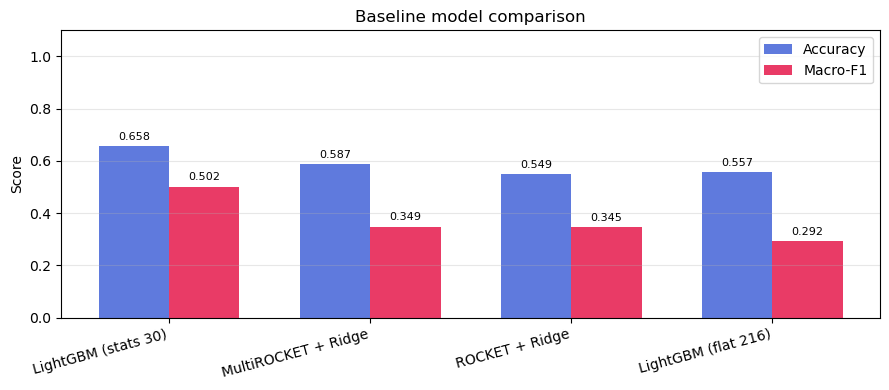

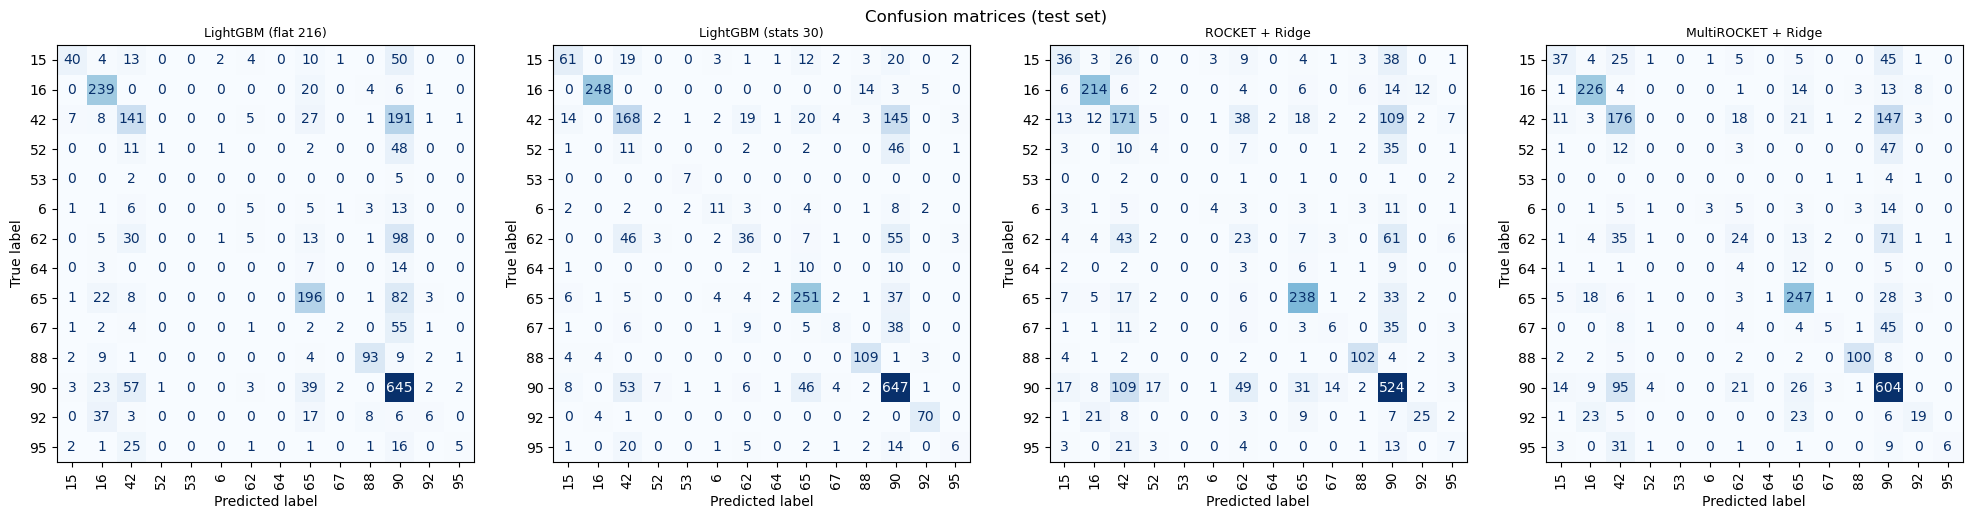

In [10]:
# ── Table ────────────────────────────────────────────────────────────────
ordered = sorted(results.items(), key=lambda x: -x[1]['macro_f1'])
print('\n' + '='*58)
print(f'{"Model":<30} {"Accuracy":>10} {"Macro-F1":>10}')
print('='*58)
for name, m in ordered:
    print(f'{name:<30} {m["acc"]*100:>9.2f}% {m["macro_f1"]:>10.4f}')
print('='*58)

# ── Bar chart (dual: accuracy + macro-F1) ────────────────────────────────
names  = [n for n, _ in ordered]
f1s    = [results[n]['macro_f1'] for n in names]
accs   = [results[n]['acc']      for n in names]
x      = np.arange(len(names))
width  = 0.35

fig, ax = plt.subplots(figsize=(9, 4))
b1 = ax.bar(x - width/2, accs,  width, label='Accuracy',  color='#4363d8', alpha=0.85)
b2 = ax.bar(x + width/2, f1s,   width, label='Macro-F1',  color='#e6194b', alpha=0.85)
ax.bar_label(b1, fmt='%.3f', padding=3, fontsize=8)
ax.bar_label(b2, fmt='%.3f', padding=3, fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Baseline model comparison')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Confusion matrices ────────────────────────────────────────────────────
labels = sorted(set(y_test))
n_models = len(all_preds)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 5))
if n_models == 1: axes = [axes]
for ax, (name, y_pred) in zip(axes, all_preds.items()):
    disp = ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=labels,
        cmap='Blues', colorbar=False, ax=ax, xticks_rotation=90
    )
    ax.set_title(name, fontsize=9)
fig.suptitle('Confusion matrices (test set)', fontsize=12)
plt.tight_layout()
plt.savefig('figures/baseline_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()